<a href="https://colab.research.google.com/github/Shusnigdha/ipl-big-data-analysis/blob/main/ipl_data_analysis_pyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install pyspark

In [2]:
from pyspark.sql.types import *

In [3]:
from pyspark.sql.functions import *

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("IPL data analysis").getOrCreate()

In [5]:
spark

In [6]:
ball_by_ball_schema = StructType([
    StructField("match_id", IntegerType(), True),
    StructField("over_id", IntegerType(), True),
    StructField("ball_id", IntegerType(), True),
    StructField("innings_no", IntegerType(), True),
    StructField("team_batting", StringType(), True),
    StructField("team_bowling", StringType(), True),
    StructField("striker_batting_position", IntegerType(), True),
    StructField("extra_type", StringType(), True),
    StructField("runs_scored", IntegerType(), True),
    StructField("extra_runs", IntegerType(), True),
    StructField("wides", IntegerType(), True),
    StructField("legbyes", IntegerType(), True),
    StructField("byes", IntegerType(), True),
    StructField("noballs", IntegerType(), True),
    StructField("penalty", IntegerType(), True),
    StructField("bowler_extras", IntegerType(), True),
    StructField("out_type", StringType(), True),
    StructField("caught", BooleanType(), True),
    StructField("bowled", BooleanType(), True),
    StructField("run_out", BooleanType(), True),
    StructField("lbw", BooleanType(), True),
    StructField("retired_hurt", BooleanType(), True),
    StructField("stumped", BooleanType(), True),
    StructField("caught_and_bowled", BooleanType(), True),
    StructField("hit_wicket", BooleanType(), True),
    StructField("obstructingfeild", BooleanType(), True),
    StructField("bowler_wicket", BooleanType(), True),
    StructField("match_date", DateType(), True),
    StructField("season", IntegerType(), True),
    StructField("striker", IntegerType(), True),
    StructField("non_striker", IntegerType(), True),
    StructField("bowler", IntegerType(), True),
    StructField("player_out", IntegerType(), True),
    StructField("fielders", IntegerType(), True),
    StructField("striker_match_sk", IntegerType(), True),
    StructField("strikersk", IntegerType(), True),
    StructField("nonstriker_match_sk", IntegerType(), True),
    StructField("nonstriker_sk", IntegerType(), True),
    StructField("fielder_match_sk", IntegerType(), True),
    StructField("fielder_sk", IntegerType(), True),
    StructField("bowler_match_sk", IntegerType(), True),
    StructField("bowler_sk", IntegerType(), True),
    StructField("playerout_match_sk", IntegerType(), True),
    StructField("battingteam_sk", IntegerType(), True),
    StructField("bowlingteam_sk", IntegerType(), True),
    StructField("keeper_catch", BooleanType(), True),
    StructField("player_out_sk", IntegerType(), True),
    StructField("matchdatesk", DateType(), True)
])

In [7]:
ball_by_ball_df = spark.read.csv(
    "Ball_By_Ball.csv",
    header=True,
    schema=ball_by_ball_schema
)

In [8]:
ball_by_ball_df.printSchema()

root
 |-- match_id: integer (nullable = true)
 |-- over_id: integer (nullable = true)
 |-- ball_id: integer (nullable = true)
 |-- innings_no: integer (nullable = true)
 |-- team_batting: string (nullable = true)
 |-- team_bowling: string (nullable = true)
 |-- striker_batting_position: integer (nullable = true)
 |-- extra_type: string (nullable = true)
 |-- runs_scored: integer (nullable = true)
 |-- extra_runs: integer (nullable = true)
 |-- wides: integer (nullable = true)
 |-- legbyes: integer (nullable = true)
 |-- byes: integer (nullable = true)
 |-- noballs: integer (nullable = true)
 |-- penalty: integer (nullable = true)
 |-- bowler_extras: integer (nullable = true)
 |-- out_type: string (nullable = true)
 |-- caught: boolean (nullable = true)
 |-- bowled: boolean (nullable = true)
 |-- run_out: boolean (nullable = true)
 |-- lbw: boolean (nullable = true)
 |-- retired_hurt: boolean (nullable = true)
 |-- stumped: boolean (nullable = true)
 |-- caught_and_bowled: boolean (null

In [9]:
ball_by_ball_df.show(5)

+--------+-------+-------+----------+------------+------------+------------------------+----------+-----------+----------+-----+-------+----+-------+-------+-------------+--------------+------+------+-------+----+------------+-------+-----------------+----------+----------------+-------------+----------+------+-------+-----------+------+----------+--------+----------------+---------+-------------------+-------------+----------------+----------+---------------+---------+------------------+--------------+--------------+------------+-------------+-----------+
|match_id|over_id|ball_id|innings_no|team_batting|team_bowling|striker_batting_position|extra_type|runs_scored|extra_runs|wides|legbyes|byes|noballs|penalty|bowler_extras|      out_type|caught|bowled|run_out| lbw|retired_hurt|stumped|caught_and_bowled|hit_wicket|obstructingfeild|bowler_wicket|match_date|season|striker|non_striker|bowler|player_out|fielders|striker_match_sk|strikersk|nonstriker_match_sk|nonstriker_sk|fielder_match_sk|

In [10]:
match_schema = StructType([
    StructField("match_sk", IntegerType(), True),
    StructField("match_id", IntegerType(), True),
    StructField("team1", StringType(), True),
    StructField("team2", StringType(), True),
    StructField("match_date", DateType(), True),
    StructField("season_year", IntegerType(), True),
    StructField("venue_name", StringType(), True),
    StructField("city_name", StringType(), True),
    StructField("country_name", StringType(), True),
    StructField("toss_winner", StringType(), True),
    StructField("match_winner", StringType(), True),
    StructField("toss_name", StringType(), True),
    StructField("win_type", StringType(), True),
    StructField("outcome_type", StringType(), True),
    StructField("manofmach", StringType(), True),
    StructField("win_margin", IntegerType(), True),
    StructField("country_id", IntegerType(), True)
])

In [11]:
match_df = spark.read.csv(
    "Match.csv",
    header=True,
    schema=match_schema
)

In [12]:
player_schema = StructType([
    StructField("player_sk", IntegerType(), True),
    StructField("player_id", IntegerType(), True),
    StructField("player_name", StringType(), True),
    StructField("dob", DateType(), True),
    StructField("batting_hand", StringType(), True),
    StructField("bowling_skill", StringType(), True),
    StructField("country_name", StringType(), True)
])

In [13]:
player_df = spark.read.csv(
    "Player.csv",
    header=True,
    schema=player_schema
)

In [14]:
player_match_schema = StructType([
    StructField("player_match_sk", IntegerType(), True),
    StructField("playermatch_key", DecimalType(10,2), True),
    StructField("match_id", IntegerType(), True),
    StructField("player_id", IntegerType(), True),
    StructField("player_name", StringType(), True),
    StructField("dob", DateType(), True),
    StructField("batting_hand", StringType(), True),
    StructField("bowling_skill", StringType(), True),
    StructField("country_name", StringType(), True),
    StructField("role_desc", StringType(), True),
    StructField("player_team", StringType(), True),
    StructField("opposit_team", StringType(), True),
    StructField("season_year", IntegerType(), True),
    StructField("is_manofthematch", BooleanType(), True),
    StructField("age_as_on_match", IntegerType(), True),
    StructField("isplayers_team_won", BooleanType(), True),
    StructField("batting_status", StringType(), True),
    StructField("bowling_status", StringType(), True),
    StructField("player_captain", StringType(), True),
    StructField("opposit_captain", StringType(), True),
    StructField("player_keeper", StringType(), True),
    StructField("opposit_keeper", StringType(), True)
])

In [15]:
player_match_df = spark.read.csv(
    "Player.csv",
    header=True,
    schema=player_schema
)

In [16]:
team_schema = StructType([
    StructField("team_sk", IntegerType(), True),
    StructField("team_id", IntegerType(), True),
    StructField("team_name", StringType(), True)
])

In [17]:
team_df = spark.read.csv(
    "Team.csv",
    header=True,
    schema=team_schema
)

In [18]:
#removing extras
clean_ball_df = ball_by_ball_df.filter(
    (ball_by_ball_df.wides == 0) &
    (ball_by_ball_df.noballs == 0) &
    (ball_by_ball_df.legbyes == 0) &
    (ball_by_ball_df.byes == 0)
)

In [19]:
#total and avg runs scored in each match and inning
total_and_avg_runs = ball_by_ball_df.groupBy("match_id", "innings_no").agg(
    sum("runs_scored").alias("total_runs"),
    avg("runs_scored").alias("avg_runs")
)
total_and_avg_runs.show()

+--------+----------+----------+------------------+
|match_id|innings_no|total_runs|          avg_runs|
+--------+----------+----------+------------------+
|  980940|         1|       138|1.1219512195121952|
|  419132|         1|       165|1.2692307692307692|
|  336009|         1|       152|1.2258064516129032|
|  501203|         1|       150|1.2396694214876034|
|  598022|         4|        11|1.8333333333333333|
|  829828|         1|       196|1.6198347107438016|
|  729308|         2|       135|1.1538461538461537|
| 1082626|         1|        62|0.5740740740740741|
|  392196|         1|       160|1.3008130081300813|
|  829794|         2|       157|1.3418803418803418|
|  598036|         2|       138|1.2212389380530972|
| 1082632|         2|       202|1.8363636363636364|
|  335993|         1|       137|1.1229508196721312|
|  501211|         2|       192|1.6551724137931034|
|  392240|         1|       141|1.0763358778625953|
|  598039|         2|       166|1.3070866141732282|
|  335993|  

In [20]:
#top run scorers
top_batsmen = clean_ball_df.groupBy("striker") \
    .sum("runs_scored")\
    .orderBy("sum(runs_scored)", ascending=False) \
    .limit(10)

top_batsmen = top_batsmen.join(
    player_df,
    top_batsmen.striker == player_df.player_id
)

top_batsmen.select("player_name","sum(runs_scored)") \
.orderBy("sum(runs_scored)", ascending=False) \
.show()

+--------------+----------------+
|   player_name|sum(runs_scored)|
+--------------+----------------+
|      SK Raina|            4526|
|       V Kohli|            4402|
|     RG Sharma|            4184|
|     G Gambhir|            4112|
|     DA Warner|            3985|
|    RV Uthappa|            3767|
|      CH Gayle|            3606|
|      MS Dhoni|            3553|
|      S Dhawan|            3541|
|AB de Villiers|            3460|
+--------------+----------------+



In [21]:
#most successful teams
team_wins = match_df.groupBy("match_winner") \
    .agg(count("*").alias("wins")) \
    .orderBy("wins", ascending=False)

team_wins.show()

+--------------------+----+
|        match_winner|wins|
+--------------------+----+
|      Mumbai Indians|  91|
| Chennai Super Kings|  79|
|Kolkata Knight Ri...|  77|
|Royal Challengers...|  73|
|     Kings XI Punjab|  70|
|    Rajasthan Royals|  63|
|    Delhi Daredevils|  62|
| Sunrisers Hyderabad|  42|
|     Deccan Chargers|  29|
|Rising Pune Super...|  15|
|       Gujarat Lions|  13|
|       Pune Warriors|  12|
|Kochi Tuskers Kerala|   6|
|                NULL|   3|
|                tied|   1|
|           abandoned|   1|
+--------------------+----+



In [22]:
#top six hitters
top_six = clean_ball_df.filter(clean_ball_df.runs_scored == 6) \
.groupBy("striker") \
.count()

top_six = top_six.join(
    player_df,
    top_six.striker == player_df.player_id
)

top_six.select("player_name","count") \
.orderBy("count", ascending=False) \
.show(10)

+--------------+-----+
|   player_name|count|
+--------------+-----+
|      CH Gayle|  261|
|      SK Raina|  173|
|     RG Sharma|  172|
|       V Kohli|  158|
|     DA Warner|  157|
|      MS Dhoni|  156|
|AB de Villiers|  155|
|     YK Pathan|  149|
|    KA Pollard|  147|
|  Yuvraj Singh|  141|
+--------------+-----+
only showing top 10 rows


In [23]:
#runs scored per season
match_ball = clean_ball_df.join(
    match_df,
    clean_ball_df.match_id == match_df.match_id
)

season_runs = match_ball.groupBy("season_year") \
.sum("runs_scored") \
.orderBy("season_year")

season_runs.show()

+-----------+----------------+
|season_year|sum(runs_scored)|
+-----------+----------------+
|       2008|           16679|
|       2009|           15281|
|       2010|           17679|
|       2011|           19826|
|       2012|           21207|
|       2013|           21408|
|       2014|           17873|
|       2015|           17363|
|       2016|           17896|
|       2017|           17855|
+-----------+----------------+



In [24]:
#total matches played per team
team_matches = match_df.groupBy("team1") \
.count() \
.orderBy("count", ascending=False)

team_matches.show()

+--------------------+-----+
|               team1|count|
+--------------------+-----+
|Royal Challengers...|   85|
|    Delhi Daredevils|   76|
| Chennai Super Kings|   74|
|     Kings XI Punjab|   72|
|      Mumbai Indians|   72|
|Kolkata Knight Ri...|   69|
|    Rajasthan Royals|   52|
|     Deccan Chargers|   39|
| Sunrisers Hyderabad|   38|
|       Pune Warriors|   23|
|       Gujarat Lions|   16|
|Rising Pune Super...|   14|
|Kochi Tuskers Kerala|    7|
+--------------------+-----+



In [27]:
#player strike rate
strike_rate = clean_ball_df.groupBy("striker") \
.agg(
    (sum("runs_scored") / count("*") * 100).alias("strike_rate")
)

strike_rate = strike_rate.join(
    player_df,
    strike_rate.striker == player_df.player_id
)

strike_rate.select("player_name","strike_rate") \
.orderBy(desc("strike_rate")) \
.show()

+---------------+------------------+
|    player_name|       strike_rate|
+---------------+------------------+
|KMDN Kulasekara|             250.0|
|      DL Chahar|233.33333333333334|
|       Umar Gul|229.41176470588235|
|       RS Sodhi|             200.0|
|      VRV Singh|             200.0|
|    BCJ Cutting| 196.8253968253968|
|  CR Brathwaite|             190.0|
|         AJ Tye|189.28571428571428|
|     ER Dwivedi| 184.6153846153846|
|  Shahid Afridi|             180.0|
|     AD Russell| 176.6153846153846|
|        SN Khan|             176.0|
|     I Malhotra|             175.0|
|      R Tewatia|             175.0|
|      KK Cooper|174.24242424242425|
|      LJ Wright| 172.8813559322034|
|     GJ Maxwell|171.80925666199158|
|     AUK Pathan|169.56521739130434|
|      LPC Silva|166.66666666666669|
|  Shivam Sharma|166.66666666666669|
+---------------+------------------+
only showing top 20 rows


In [28]:
#rank batsmen using window function
from pyspark.sql.window import Window

# Total runs per striker
runs_df = clean_ball_df.groupBy("striker") \
    .agg(sum("runs_scored").alias("total_runs"))

# Join with player table to get names
runs_with_names = runs_df.join(
    player_df,
    runs_df.striker == player_df.player_id,
    "inner"
)

# Window ranking
window_spec = Window.orderBy(col("total_runs").desc())

ranked_batsmen = runs_with_names.withColumn(
    "rank",
    rank().over(window_spec)
)

# Show result
ranked_batsmen.select("player_name","total_runs","rank").show(10)

+--------------+----------+----+
|   player_name|total_runs|rank|
+--------------+----------+----+
|      SK Raina|      4526|   1|
|       V Kohli|      4402|   2|
|     RG Sharma|      4184|   3|
|     G Gambhir|      4112|   4|
|     DA Warner|      3985|   5|
|    RV Uthappa|      3767|   6|
|      CH Gayle|      3606|   7|
|      MS Dhoni|      3553|   8|
|      S Dhawan|      3541|   9|
|AB de Villiers|      3460|  10|
+--------------+----------+----+
only showing top 10 rows


In [29]:
#top scorer per match

# total runs scored by each player in each match
runs_match = clean_ball_df.groupBy("match_id", "striker") \
    .agg(sum("runs_scored").alias("runs_in_match"))

# window for ranking players within each match
window_spec = Window.partitionBy("match_id") \
                    .orderBy(col("runs_in_match").desc())

# assign rank
ranked_players = runs_match.withColumn(
    "rank",
    rank().over(window_spec)
)

# keep only top scorer of each match
top_scorer_match = ranked_players.filter(col("rank") == 1)

# join with player table to get player names
top_scorer_match = top_scorer_match.join(
    player_df,
    top_scorer_match.striker == player_df.player_id,
    "inner"
)

# show final result
top_scorer_match.select(
    "match_id",
    "player_name",
    "runs_in_match"
).orderBy("match_id").show()

+--------+-------------+-------------+
|match_id|  player_name|runs_in_match|
+--------+-------------+-------------+
|  335987|  BB McCullum|          158|
|  335988|   MEK Hussey|          116|
|  335989|    G Gambhir|           58|
|  335990|   RV Uthappa|           48|
|  335991|    DJ Hussey|           38|
|  335992|    SR Watson|           75|
|  335993|     V Sehwag|           94|
|  335994|    ML Hayden|           76|
|  335995|    A Symonds|          117|
|  335996|KC Sangakkara|           94|
|  335997|    SR Watson|           61|
|  335998|    ML Hayden|           69|
|  335999| AC Gilchrist|          109|
|  336000|    SM Katich|           74|
|  336001|     MS Dhoni|           65|
|  336002|     DJ Bravo|           64|
|  336003|    G Gambhir|           84|
|  336004|     SE Marsh|           84|
|  336005|  SA Asnodkar|           60|
|  336006|     V Sehwag|           64|
+--------+-------------+-------------+
only showing top 20 rows


In [30]:
#Running total of runs in a match
window_spec = Window.partitionBy("match_id") \
                    .orderBy("over_id", "ball_id") \
                    .rowsBetween(Window.unboundedPreceding, Window.currentRow)

running_score = clean_ball_df.withColumn(
    "cumulative_runs",
    sum("runs_scored").over(window_spec)
)

running_score.select(
    "match_id",
    "over_id",
    "ball_id",
    "runs_scored",
    "cumulative_runs"
).show()

+--------+-------+-------+-----------+---------------+
|match_id|over_id|ball_id|runs_scored|cumulative_runs|
+--------+-------+-------+-----------+---------------+
|  335987|      1|      1|          1|              1|
|  335987|      1|      2|          0|              1|
|  335987|      1|      3|          0|              1|
|  335987|      1|      4|          0|              1|
|  335987|      1|      4|          1|              2|
|  335987|      1|      5|          0|              2|
|  335987|      1|      5|          1|              3|
|  335987|      1|      6|          0|              3|
|  335987|      1|      6|          0|              3|
|  335987|      1|      7|          0|              3|
|  335987|      2|      1|          0|              3|
|  335987|      2|      1|          0|              3|
|  335987|      2|      2|          4|              7|
|  335987|      2|      2|          0|              7|
|  335987|      2|      3|          4|             11|
|  335987|

In [31]:
#season-wise player ranking

# Join ball data with match table to get season
season_df = clean_ball_df.join(
    match_df,
    clean_ball_df.match_id == match_df.match_id,
    "inner"
)

# Runs scored by each player per season
season_runs = season_df.groupBy("season_year", "striker") \
    .agg(sum("runs_scored").alias("total_runs"))

# Window to rank players within each season
window_spec = Window.partitionBy("season_year") \
                    .orderBy(col("total_runs").desc())

season_rank = season_runs.withColumn(
    "rank",
    rank().over(window_spec)
)

# Keep top 5 players per season
top5_season_players = season_rank.filter(col("rank") <= 5)

# Join player table to get names
top5_season_players = top5_season_players.join(
    player_df,
    top5_season_players.striker == player_df.player_id,
    "inner"
)

# Final result
top5_season_players.select(
    "season_year",
    "player_name",
    "total_runs",
    "rank"
).orderBy("season_year","rank").show()

+-----------+--------------+----------+----+
|season_year|   player_name|total_runs|rank|
+-----------+--------------+----------+----+
|       2008|      SE Marsh|       614|   1|
|       2008|     G Gambhir|       532|   2|
|       2008| ST Jayasuriya|       508|   3|
|       2008|     SR Watson|       463|   4|
|       2008|      GC Smith|       437|   5|
|       2009|     ML Hayden|       571|   1|
|       2009|  AC Gilchrist|       486|   2|
|       2009|AB de Villiers|       459|   3|
|       2009|      SK Raina|       433|   4|
|       2009|    TM Dilshan|       414|   5|
|       2010|  SR Tendulkar|       615|   1|
|       2010|     JH Kallis|       566|   2|
|       2010|      SK Raina|       520|   3|
|       2010|    SC Ganguly|       493|   4|
|       2010|       M Vijay|       458|   5|
|       2011|      CH Gayle|       598|   1|
|       2011|       V Kohli|       557|   2|
|       2011|  SR Tendulkar|       553|   3|
|       2011|      SE Marsh|       500|   4|
|       20

In [43]:
#boundary analysis
boundary_df = clean_ball_df.filter(
    (clean_ball_df.runs_scored == 4) |
    (clean_ball_df.runs_scored == 6)
).groupBy("runs_scored") \
 .count().show()

+-----------+-----+
|runs_scored|count|
+-----------+-----+
|          6| 6482|
|          4|16947|
+-----------+-----+



Visualization:


In [32]:
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
top_batsmen_pd = top_batsmen \
    .select("player_name","sum(runs_scored)") \
    .toPandas()

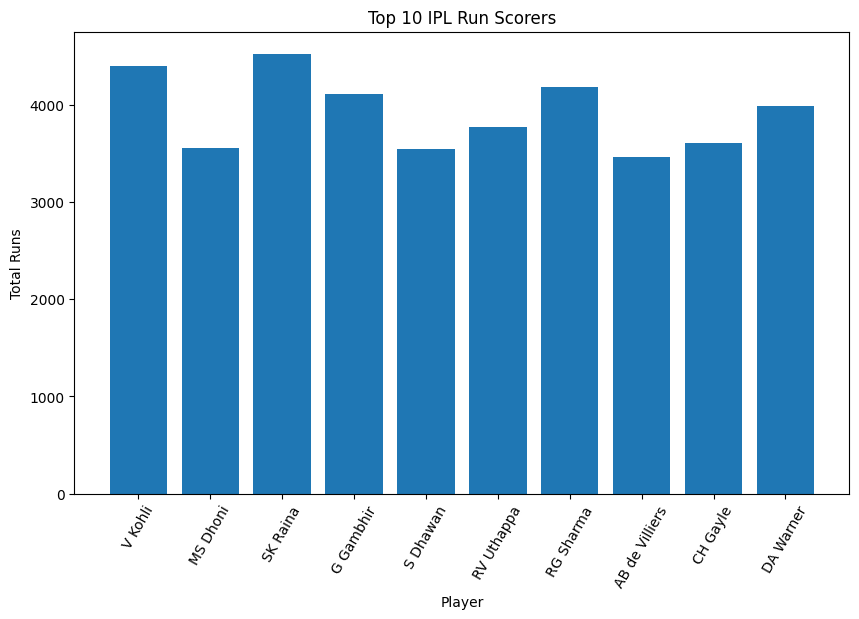

In [34]:
plt.figure(figsize=(10,6))
plt.bar(top_batsmen_pd["player_name"], top_batsmen_pd["sum(runs_scored)"])
plt.xticks(rotation=60)
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.show()

In [35]:
team_wins_pd = team_wins.toPandas()

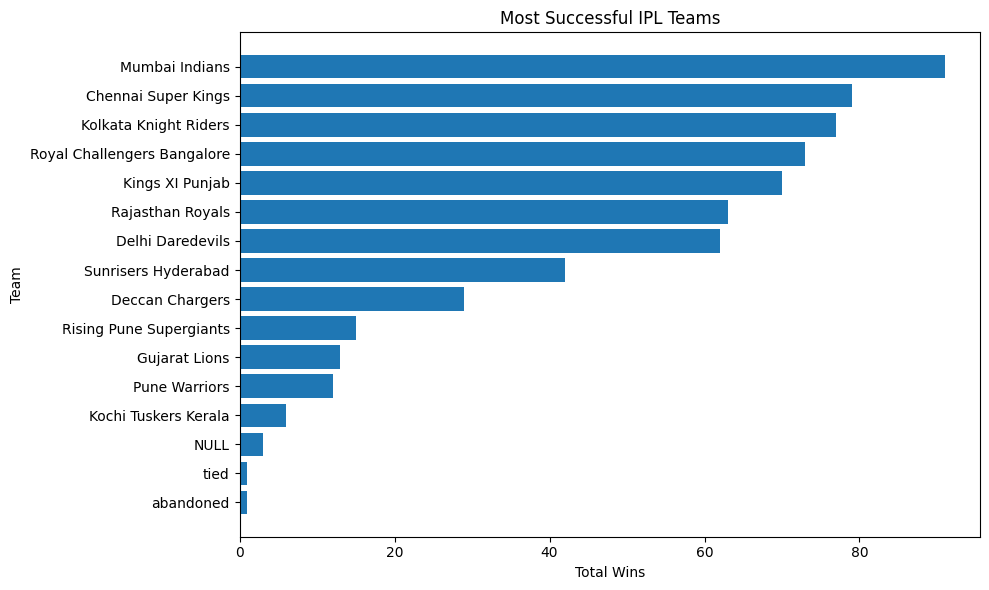

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    team_wins_pd["match_winner"],
    team_wins_pd["wins"]
)

plt.title("Most Successful IPL Teams")
plt.xlabel("Total Wins")
plt.ylabel("Team")

plt.gca().invert_yaxis()   # highest wins on top
plt.tight_layout()

plt.show()

In [40]:
boundary_pd = boundary_df.toPandas()

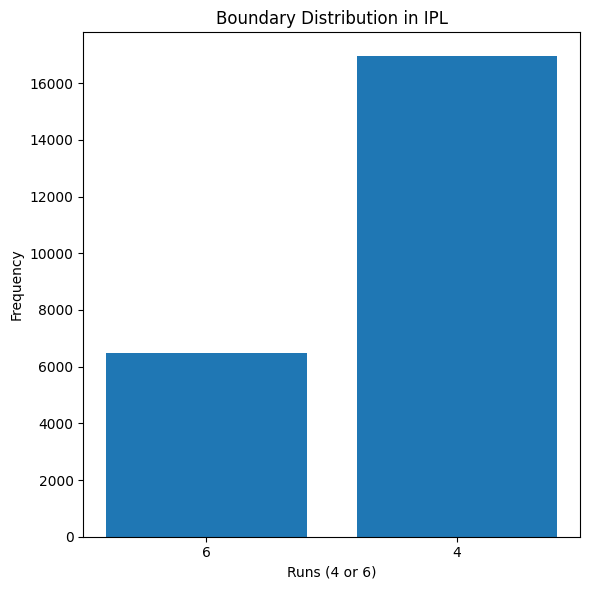

In [41]:
plt.figure(figsize=(6,6))

plt.bar(
    boundary_pd["runs_scored"].astype(str),
    boundary_pd["count"]
)

plt.title("Boundary Distribution in IPL")
plt.xlabel("Runs (4 or 6)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()